DATASET
   CGPA  AptitudeScore  CommunicationScore  Internships  Projects Department  \
0  7.11             63                  97            0         3         IT   
1  9.59             91                  94            2         5        ECE   
2  8.65             50                  65            3         2         IT   
3  8.07             88                  76            0         1      AI-DS   
4  6.17             47                  65            2         3         IT   

   Gender  
0  Female  
1    Male  
2    Male  
3    Male  
4  Female  

Dataset Shape:
(200, 7)

CLUSTERING FEATURES
['CGPA', 'AptitudeScore', 'CommunicationScore', 'Internships', 'Projects']

STANDARDIZATION COMPLETED
Scaled Data Shape: (200, 5)


K-MEANS ELBOW METHOD

K	Inertia
2 	 818.54
3 	 710.33
4 	 629.07
5 	 564.45
6 	 518.1
7 	 476.81
8 	 448.04
9 	 417.09
10 	 390.29


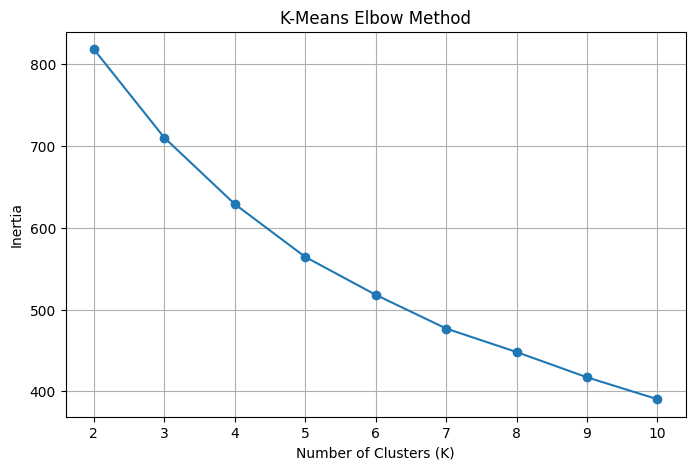



K-MEANS SILHOUETTE ANALYSIS

K	Silhouette Score
2 	 0.1751
3 	 0.1641
4 	 0.1752
5 	 0.1813
6 	 0.1851
7 	 0.1804
8 	 0.1773
9 	 0.1841
10 	 0.1921


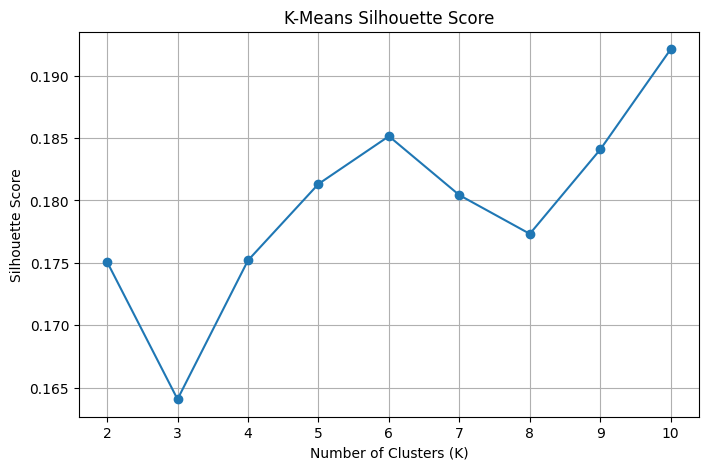


BEST K BASED ON SILHOUETTE SCORE
Best K: 10
Best Silhouette Score: 0.1921


FINAL K-MEANS
Number of Clusters: 10

Cluster Counts:
KMeans_Cluster
0    23
1    21
2    22
3    21
4    15
5    18
6    22
7    26
8    12
9    20
Name: count, dtype: int64


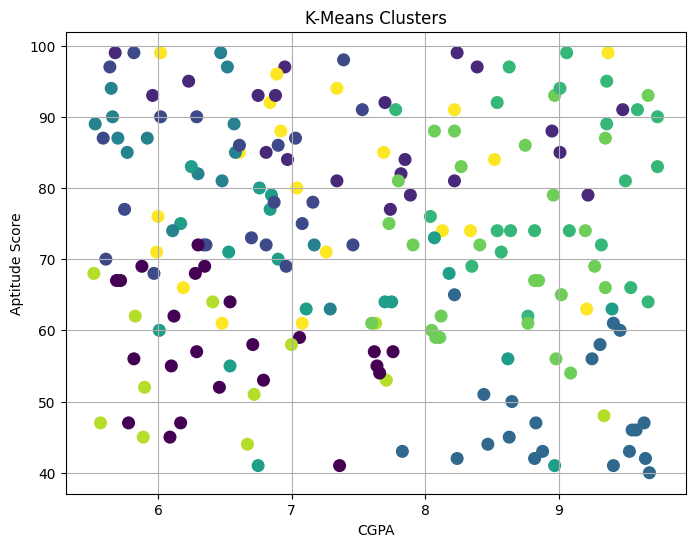



MINIBATCH K-MEANS TIMING
Normal K-Means Time: 0.087184 seconds
MiniBatch K-Means Time: 0.048534 seconds
MiniBatch K-Means Silhouette: 0.1632


HIERARCHICAL CLUSTERING
Number of Clusters: 10
Silhouette Score: 0.1607

Cluster Counts:
Hierarchical_Cluster
0    31
1    28
2    20
3    20
4    22
5    25
6    16
7    15
8     9
9    14
Name: count, dtype: int64


HIERARCHICAL DENDROGRAM


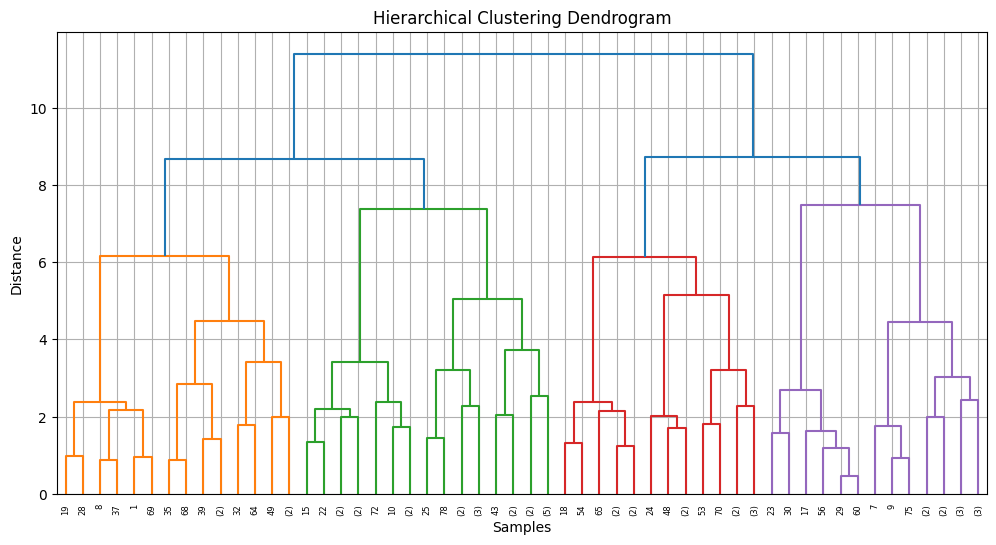



DBSCAN K-DISTANCE ANALYSIS
min_samples: 6


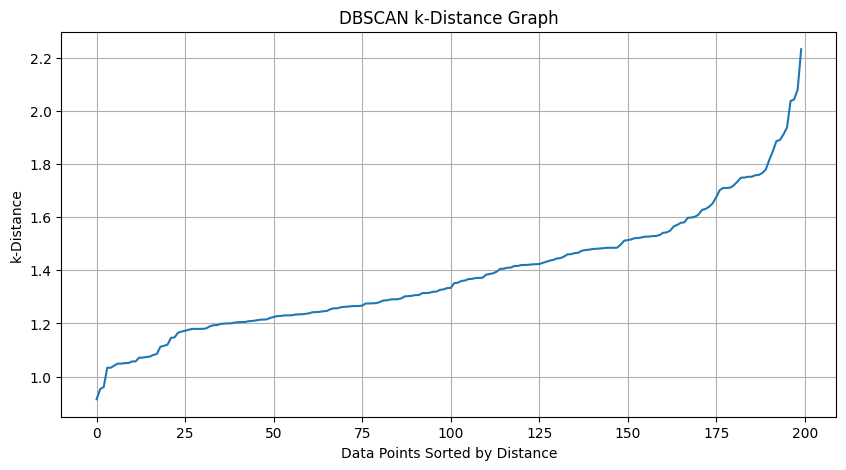


DBSCAN EPSILON
Selected epsilon: 1.5


DBSCAN CLUSTERING
Number of DBSCAN Clusters: 1
Number of Noise Points: 4

Cluster Counts:
DBSCAN_Cluster
-1      4
 0    196
Name: count, dtype: int64

DBSCAN Silhouette Score: Not available because fewer than 2 clusters were formed.


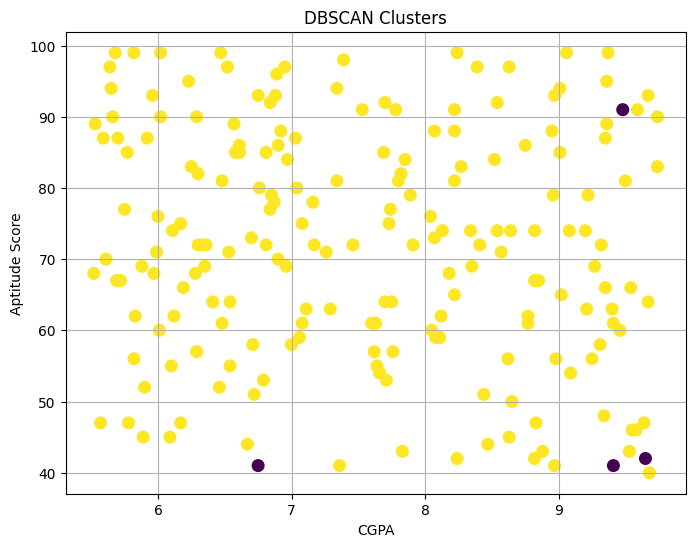



K-MEANS CLUSTER PROFILE
                CGPA  AptitudeScore  CommunicationScore  Internships  \
KMeans_Cluster                                                         
0               6.53          57.87               75.22         2.65   
1               7.62          88.29               58.29         0.38   
2               6.54          81.23               53.95         0.91   
3               9.02          48.19               71.57         2.00   
4               6.25          84.93               89.93         1.67   
5               7.30          65.72               86.44         0.17   
6               8.98          80.82               87.91         2.23   
7               8.59          72.19               61.54         0.73   
8               6.68          54.42               59.67         0.08   
9               7.31          80.50               59.05         2.50   

                Projects  Count  
KMeans_Cluster                   
0                   3.17     23  
1      

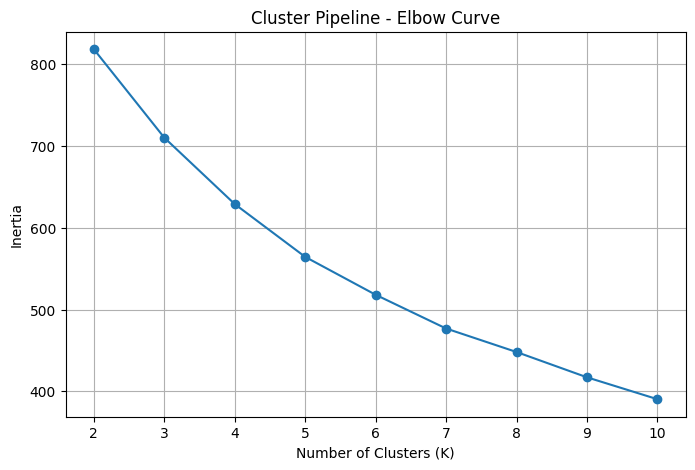

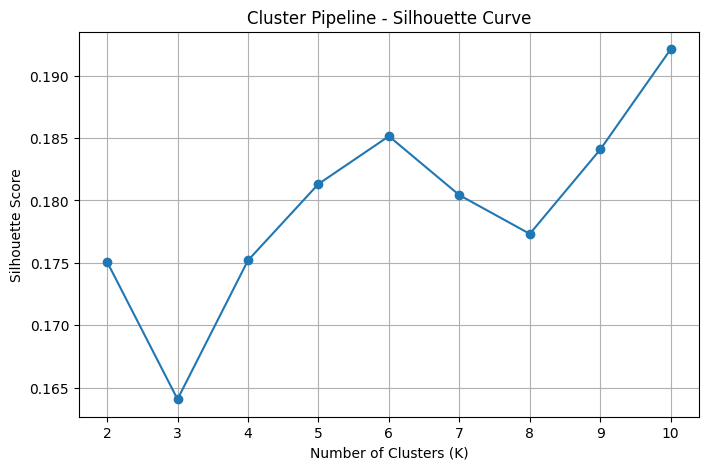


CLUSTER PIPELINE SUMMARY
 K  Inertia  Silhouette
 2 818.5356      0.1751
 3 710.3265      0.1641
 4 629.0664      0.1752
 5 564.4465      0.1813
 6 518.0964      0.1851
 7 476.8074      0.1804
 8 448.0410      0.1773
 9 417.0878      0.1841
10 390.2930      0.1921

BEST CLUSTERING RESULT
Best K: 10
Inertia: 390.293
Silhouette Score: 0.1921


CLUSTERING METHOD COMPARISON
           Method  Silhouette Score
          K-Means            0.1921
MiniBatch K-Means            0.1632
     Hierarchical            0.1607
           DBSCAN               NaN


SESSION 9 COMPLETED SUCCESSFULLY
K-Means Best K: 10
K-Means Silhouette: 0.1921
MiniBatch K-Means Time: 0.048534 seconds
Hierarchical Silhouette: 0.1607
DBSCAN Clusters: 1
DBSCAN Noise Points: 4

Cluster Pipeline Completed Successfully.
All Session 9 tasks completed.


In [1]:
# ============================================================
# SESSION 9 - CLUSTERING
# ============================================================
# Topics:
# 1. K-Means Elbow Method
# 2. K-Means Silhouette Score
# 3. MiniBatchKMeans Timing
# 4. Hierarchical Clustering + Dendrogram
# 5. DBSCAN k-distance + Epsilon
# 6. Cluster Profile Table
# 7. cluster_pipeline() Function
# ============================================================


# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    MiniBatchKMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)


# ============================================================
# 2. CREATE STUDENT DATASET
# ============================================================

np.random.seed(42)

n = 200

df = pd.DataFrame({

    "CGPA": np.round(
        np.random.uniform(5.5, 9.8, n),
        2
    ),

    "AptitudeScore": np.random.randint(
        40, 100, n
    ),

    "CommunicationScore": np.random.randint(
        40, 100, n
    ),

    "Internships": np.random.randint(
        0, 4, n
    ),

    "Projects": np.random.randint(
        1, 6, n
    ),

    "Department": np.random.choice(
        ["CSE", "IT", "AI-DS", "ECE"],
        n
    ),

    "Gender": np.random.choice(
        ["Male", "Female"],
        n
    )
})


# ============================================================
# 3. DISPLAY DATASET
# ============================================================

print("================================================")
print("DATASET")
print("================================================")

print(df.head())

print("\nDataset Shape:")
print(df.shape)


# ============================================================
# 4. SELECT NUMERICAL FEATURES
# ============================================================

cluster_features = [
    "CGPA",
    "AptitudeScore",
    "CommunicationScore",
    "Internships",
    "Projects"
]

X = df[cluster_features].copy()


print("\n================================================")
print("CLUSTERING FEATURES")
print("================================================")

print(cluster_features)


# ============================================================
# 5. STANDARDIZE DATA
# ============================================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


print("\n================================================")
print("STANDARDIZATION COMPLETED")
print("================================================")

print("Scaled Data Shape:", X_scaled.shape)


# ============================================================
# 6. K-MEANS ELBOW METHOD
# ============================================================

print("\n\n================================================")
print("K-MEANS ELBOW METHOD")
print("================================================")

k_values = range(2, 11)

inertias = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertias.append(
        kmeans.inertia_
    )


print("\nK\tInertia")

for k, inertia in zip(
    k_values,
    inertias
):

    print(
        k,
        "\t",
        round(inertia, 2)
    )


# ------------------------------------------------------------
# ELBOW GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Inertia"
)

plt.title(
    "K-Means Elbow Method"
)

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()


# ============================================================
# 7. K-MEANS SILHOUETTE SCORE
# ============================================================

print("\n\n================================================")
print("K-MEANS SILHOUETTE ANALYSIS")
print("================================================")

silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(
        X_scaled
    )

    score = silhouette_score(
        X_scaled,
        labels
    )

    silhouette_scores.append(
        score
    )


print("\nK\tSilhouette Score")

for k, score in zip(
    k_values,
    silhouette_scores
):

    print(
        k,
        "\t",
        round(score, 4)
    )


# ------------------------------------------------------------
# SILHOUETTE GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel(
    "Number of Clusters (K)"
)

plt.ylabel(
    "Silhouette Score"
)

plt.title(
    "K-Means Silhouette Score"
)

plt.xticks(
    list(k_values)
)

plt.grid(True)

plt.show()


# ============================================================
# 8. SELECT BEST K USING SILHOUETTE
# ============================================================

best_k = list(
    k_values
)[
    np.argmax(
        silhouette_scores
    )
]


print("\n================================================")
print("BEST K BASED ON SILHOUETTE SCORE")
print("================================================")

print(
    "Best K:",
    best_k
)

print(
    "Best Silhouette Score:",
    round(
        max(silhouette_scores),
        4
    )
)


# ============================================================
# 9. FINAL K-MEANS MODEL
# ============================================================

print("\n\n================================================")
print("FINAL K-MEANS")
print("================================================")

kmeans_final = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(
    X_scaled
)

df["KMeans_Cluster"] = kmeans_labels


print(
    "Number of Clusters:",
    best_k
)

print("\nCluster Counts:")

print(
    df["KMeans_Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 10. K-MEANS 2D VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    df["CGPA"],
    df["AptitudeScore"],
    c=df["KMeans_Cluster"],
    s=70,
    cmap="viridis"
)

plt.xlabel(
    "CGPA"
)

plt.ylabel(
    "Aptitude Score"
)

plt.title(
    "K-Means Clusters"
)

plt.grid(True)

plt.show()


# ============================================================
# 11. MINIBATCH K-MEANS TIMING
# ============================================================

print("\n\n================================================")
print("MINIBATCH K-MEANS TIMING")
print("================================================")

# Normal K-Means timing

start_time = time.time()

normal_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

normal_kmeans.fit(
    X_scaled
)

normal_time = (
    time.time() - start_time
)


# MiniBatch K-Means timing

start_time = time.time()

mini_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    batch_size=32,
    random_state=42,
    n_init=10
)

mini_labels = mini_kmeans.fit_predict(
    X_scaled
)

mini_time = (
    time.time() - start_time
)


print(
    "Normal K-Means Time:",
    round(normal_time, 6),
    "seconds"
)

print(
    "MiniBatch K-Means Time:",
    round(mini_time, 6),
    "seconds"
)


# ============================================================
# 12. MINI-BATCH K-MEANS QUALITY
# ============================================================

mini_silhouette = silhouette_score(
    X_scaled,
    mini_labels
)

print(
    "MiniBatch K-Means Silhouette:",
    round(
        mini_silhouette,
        4
    )
)


# ============================================================
# 13. HIERARCHICAL CLUSTERING
# ============================================================

print("\n\n================================================")
print("HIERARCHICAL CLUSTERING")
print("================================================")

hierarchical = AgglomerativeClustering(
    n_clusters=best_k,
    linkage="ward"
)

hierarchical_labels = (
    hierarchical.fit_predict(
        X_scaled
    )
)

df["Hierarchical_Cluster"] = (
    hierarchical_labels
)


hierarchical_silhouette = (
    silhouette_score(
        X_scaled,
        hierarchical_labels
    )
)


print(
    "Number of Clusters:",
    best_k
)

print(
    "Silhouette Score:",
    round(
        hierarchical_silhouette,
        4
    )
)

print("\nCluster Counts:")

print(
    df["Hierarchical_Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 14. HIERARCHICAL DENDROGRAM
# ============================================================

print("\n\n================================================")
print("HIERARCHICAL DENDROGRAM")
print("================================================")

# Use a sample to keep the dendrogram readable

sample_size = min(
    80,
    len(X_scaled)
)

sample_indices = np.random.choice(
    len(X_scaled),
    size=sample_size,
    replace=False
)

X_dendrogram = (
    X_scaled[sample_indices]
)


linkage_matrix = linkage(
    X_dendrogram,
    method="ward"
)


plt.figure(
    figsize=(12, 6)
)

dendrogram(
    linkage_matrix,
    truncate_mode="level",
    p=5
)

plt.xlabel(
    "Samples"
)

plt.ylabel(
    "Distance"
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.grid(True)

plt.show()


# ============================================================
# 15. DBSCAN K-DISTANCE GRAPH
# ============================================================

print("\n\n================================================")
print("DBSCAN K-DISTANCE ANALYSIS")
print("================================================")

# For DBSCAN, choose min_samples based on the
# number of dimensions.

min_samples_dbscan = (
    X_scaled.shape[1] + 1
)

print(
    "min_samples:",
    min_samples_dbscan
)


neighbors = NearestNeighbors(
    n_neighbors=min_samples_dbscan
)

neighbors.fit(
    X_scaled
)


distances, indices = (
    neighbors.kneighbors(
        X_scaled
    )
)


# Distance to kth nearest neighbor

k_distances = distances[
    :,
    min_samples_dbscan - 1
]


k_distances = np.sort(
    k_distances
)


plt.figure(
    figsize=(10, 5)
)

plt.plot(
    k_distances
)

plt.xlabel(
    "Data Points Sorted by Distance"
)

plt.ylabel(
    "k-Distance"
)

plt.title(
    "DBSCAN k-Distance Graph"
)

plt.grid(True)

plt.show()


# ============================================================
# 16. AUTOMATIC EPSILON ESTIMATION
# ============================================================

# Use a percentile of k-distances.
# This avoids manually guessing epsilon.

epsilon = float(
    np.percentile(
        k_distances,
        90
    )
)

# Keep epsilon within a practical range
epsilon = max(
    0.30,
    min(
        epsilon,
        1.50
    )
)


print("\n================================================")
print("DBSCAN EPSILON")
print("================================================")

print(
    "Selected epsilon:",
    round(
        epsilon,
        4
    )
)


# ============================================================
# 17. DBSCAN
# ============================================================

print("\n\n================================================")
print("DBSCAN CLUSTERING")
print("================================================")

dbscan = DBSCAN(
    eps=epsilon,
    min_samples=min_samples_dbscan
)

dbscan_labels = dbscan.fit_predict(
    X_scaled
)

df["DBSCAN_Cluster"] = (
    dbscan_labels
)


# Number of clusters excluding noise

unique_labels = set(
    dbscan_labels
)

dbscan_cluster_count = (
    len(unique_labels)
    -
    (1 if -1 in unique_labels else 0)
)


noise_count = np.sum(
    dbscan_labels == -1
)


print(
    "Number of DBSCAN Clusters:",
    dbscan_cluster_count
)

print(
    "Number of Noise Points:",
    noise_count
)

print("\nCluster Counts:")

print(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)


# ============================================================
# 18. DBSCAN SILHOUETTE
# ============================================================

if dbscan_cluster_count >= 2:

    non_noise_mask = (
        dbscan_labels != -1
    )

    if (
        len(
            set(
                dbscan_labels[
                    non_noise_mask
                ]
            )
        ) >= 2
    ):

        dbscan_silhouette = (
            silhouette_score(
                X_scaled[
                    non_noise_mask
                ],
                dbscan_labels[
                    non_noise_mask
                ]
            )
        )

        print(
            "\nDBSCAN Silhouette Score:",
            round(
                dbscan_silhouette,
                4
            )
        )

    else:

        dbscan_silhouette = np.nan

        print(
            "\nDBSCAN Silhouette Score: "
            "Not available"
        )

else:

    dbscan_silhouette = np.nan

    print(
        "\nDBSCAN Silhouette Score: "
        "Not available because fewer than 2 clusters were formed."
    )


# ============================================================
# 19. DBSCAN VISUALIZATION
# ============================================================

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    df["CGPA"],
    df["AptitudeScore"],
    c=df["DBSCAN_Cluster"],
    s=70,
    cmap="viridis"
)

plt.xlabel(
    "CGPA"
)

plt.ylabel(
    "Aptitude Score"
)

plt.title(
    "DBSCAN Clusters"
)

plt.grid(True)

plt.show()


# ============================================================
# 20. CLUSTER PROFILE TABLE - K-MEANS
# ============================================================

print("\n\n================================================")
print("K-MEANS CLUSTER PROFILE")
print("================================================")

cluster_profile = (
    df
    .groupby(
        "KMeans_Cluster"
    )[cluster_features]
    .mean()
    .round(2)
)


cluster_profile["Count"] = (
    df
    .groupby(
        "KMeans_Cluster"
    )
    .size()
)


print(
    cluster_profile
)


# ============================================================
# 21. CLUSTER PROFILE INCLUDING DEPARTMENT
# ============================================================

print("\n\n================================================")
print("CLUSTER DEPARTMENT PROFILE")
print("================================================")

department_profile = pd.crosstab(
    df["KMeans_Cluster"],
    df["Department"]
)

print(
    department_profile
)


# ============================================================
# 22. CLUSTER PIPELINE FUNCTION
# ============================================================

def cluster_pipeline(
    X_scaled,
    k_range
):

    labels_array = {}

    summary = []

    for k in k_range:

        # ----------------------------------------------------
        # K-MEANS
        # ----------------------------------------------------

        model = KMeans(
            n_clusters=k,
            random_state=42,
            n_init=10
        )

        labels = (
            model.fit_predict(
                X_scaled
            )
        )


        # ----------------------------------------------------
        # INERTIA
        # ----------------------------------------------------

        inertia = (
            model.inertia_
        )


        # ----------------------------------------------------
        # SILHOUETTE
        # ----------------------------------------------------

        silhouette = (
            silhouette_score(
                X_scaled,
                labels
            )
        )


        # ----------------------------------------------------
        # STORE LABELS
        # ----------------------------------------------------

        labels_array[k] = labels


        # ----------------------------------------------------
        # STORE SUMMARY
        # ----------------------------------------------------

        summary.append({

            "K": k,

            "Inertia": inertia,

            "Silhouette": silhouette

        })


    # --------------------------------------------------------
    # CREATE SUMMARY DATAFRAME
    # --------------------------------------------------------

    summary_df = pd.DataFrame(
        summary
    )


    # --------------------------------------------------------
    # PLOT INERTIA
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        summary_df["K"],
        summary_df["Inertia"],
        marker="o"
    )

    plt.xlabel(
        "Number of Clusters (K)"
    )

    plt.ylabel(
        "Inertia"
    )

    plt.title(
        "Cluster Pipeline - Elbow Curve"
    )

    plt.grid(True)

    plt.show()


    # --------------------------------------------------------
    # PLOT SILHOUETTE
    # --------------------------------------------------------

    plt.figure(
        figsize=(8, 5)
    )

    plt.plot(
        summary_df["K"],
        summary_df["Silhouette"],
        marker="o"
    )

    plt.xlabel(
        "Number of Clusters (K)"
    )

    plt.ylabel(
        "Silhouette Score"
    )

    plt.title(
        "Cluster Pipeline - Silhouette Curve"
    )

    plt.grid(True)

    plt.show()


    return (
        labels_array,
        summary_df
    )


# ============================================================
# 23. RUN CLUSTER PIPELINE
# ============================================================

print("\n\n================================================")
print("CLUSTER PIPELINE")
print("================================================")

k_range = range(
    2,
    11
)


labels_array, summary_df = (
    cluster_pipeline(
        X_scaled,
        k_range
    )
)


# ============================================================
# 24. DISPLAY PIPELINE SUMMARY
# ============================================================

print("\n================================================")
print("CLUSTER PIPELINE SUMMARY")
print("================================================")

print(
    summary_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 25. FIND BEST K FROM PIPELINE
# ============================================================

best_pipeline_row = (
    summary_df.loc[
        summary_df["Silhouette"].idxmax()
    ]
)


print("\n================================================")
print("BEST CLUSTERING RESULT")
print("================================================")

print(
    "Best K:",
    int(
        best_pipeline_row["K"]
    )
)

print(
    "Inertia:",
    round(
        best_pipeline_row["Inertia"],
        4
    )
)

print(
    "Silhouette Score:",
    round(
        best_pipeline_row["Silhouette"],
        4
    )
)


# ============================================================
# 26. COMPARISON OF CLUSTERING METHODS
# ============================================================

print("\n\n================================================")
print("CLUSTERING METHOD COMPARISON")
print("================================================")


comparison_data = {

    "Method": [
        "K-Means",
        "MiniBatch K-Means",
        "Hierarchical",
        "DBSCAN"
    ],

    "Silhouette Score": [

        silhouette_score(
            X_scaled,
            kmeans_labels
        ),

        mini_silhouette,

        hierarchical_silhouette,

        dbscan_silhouette
    ]
}


comparison_df = pd.DataFrame(
    comparison_data
)


print(
    comparison_df.round(4).to_string(
        index=False
    )
)


# ============================================================
# 27. FINAL CLUSTERING SUMMARY
# ============================================================

print("\n\n================================================")
print("SESSION 9 COMPLETED SUCCESSFULLY")
print("================================================")

print(
    "K-Means Best K:",
    best_k
)

print(
    "K-Means Silhouette:",
    round(
        silhouette_score(
            X_scaled,
            kmeans_labels
        ),
        4
    )
)

print(
    "MiniBatch K-Means Time:",
    round(
        mini_time,
        6
    ),
    "seconds"
)

print(
    "Hierarchical Silhouette:",
    round(
        hierarchical_silhouette,
        4
    )
)

print(
    "DBSCAN Clusters:",
    dbscan_cluster_count
)

print(
    "DBSCAN Noise Points:",
    noise_count
)

print(
    "\nCluster Pipeline Completed Successfully."
)

print(
    "All Session 9 tasks completed."
)